# **Import Necessary library**

In [39]:
import pandas as pd          
import numpy as np           
from sklearn.linear_model import LinearRegression   
from sklearn.model_selection import train_test_split 
from sklearn.metrics import mean_absolute_error      
from sklearn.metrics import r2_score                 
from sklearn.metrics import mean_squared_error       
import matplotlib.pyplot as plt  
import seaborn as sns             
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
print("All libraries loaded successfully ✅")

All libraries loaded successfully ✅


# **Data Exploration**

## *Load the Data*

In [40]:
df = pd.read_csv("C:\\Users\\abhay\\OneDrive\\Desktop\\ML learning\\Linear Regression\\Formula 1\\Data\\f1_raw.csv")
print("Data Loaded")

Data Loaded


## *Explore*

In [41]:
print("Shape:", df.shape)

Shape: (510, 7)


In [42]:
df.head()

,driver,tyre_compound,tyre_age,fuel_load,track_temp,starting_position,lap_time
0,Norris,Hard,NaN,28.2,51.8,14,101.155
1,Verstappen,Soft,29.0,64.5,49.0,12,100.545
2,Norris,Medium,15.0,25.2,37.8,10,93.623
3,Hamilton,Medium,8.0,69.5,25.7,20,94.530
4,Hamilton,Soft,21.0,59.7,33.1,18,96.924


In [43]:
df.tail()

,driver,tyre_compound,tyre_age,fuel_load,track_temp,starting_position,lap_time
505,Perez,Hard,7.0,50.8,49.2,-5,91.883
506,Alonso,Soft,27.0,300.0,31.4,3,99.344
507,Verstappen,Medium,7.0,101.6,52.4,10,95.182
508,Sainz,Medium,18.0,100.7,54.4,8,99.177
509,Norris,Soft,28.0,103.9,53.3,12,102.136


In [44]:
print("Data types:")
print(df.dtypes)

Data types:
driver                object
tyre_compound         object
tyre_age             float64
fuel_load            float64
track_temp           float64
starting_position      int64
lap_time             float64
dtype: object


In [45]:
df.isnull().sum()

driver                0
tyre_compound         0
tyre_age             15
fuel_load            15
track_temp            0
starting_position     0
lap_time              0
dtype: int64

In [46]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 5


In [47]:
df.describe()

,tyre_age,fuel_load,track_temp,starting_position,lap_time
count,495.000000,495.000000,510.000000,510.000000,510.000000
mean,21.262626,64.460808,40.269804,10.147059,97.840294
std,13.433285,28.524187,8.917506,5.829936,9.178374
min,1.000000,20.400000,25.200000,-5.000000,-12.300000
25%,11.000000,40.150000,32.125000,5.000000,94.886750
50%,22.000000,62.500000,40.600000,10.000000,97.838000
75%,31.000000,87.400000,48.100000,15.000000,100.840250
max,180.000000,300.000000,54.900000,20.000000,245.500000


# **Data Cleaning**

In [48]:
df_clean = df.copy()
print("Copy created")

Copy created


In [49]:
# DataType correction
df_clean['tyre_age'] = pd.to_numeric(df_clean['tyre_age'], errors='coerce')
df_clean['lap_time'] = pd.to_numeric(df_clean['lap_time'], errors='coerce')
print(df_clean[['tyre_age', 'lap_time']].dtypes)

tyre_age    float64
lap_time    float64
dtype: object


In [50]:
# Inconsistent Category Values
df_clean['tyre_compound'] = df_clean['tyre_compound'].str.strip().str.title()
df_clean['driver'] = df_clean['driver'].str.strip().str.title()
print(df_clean['tyre_compound'].unique())
print(df_clean['driver'].unique())

['Hard' 'Soft' 'Medium']
['Norris' 'Verstappen' 'Hamilton' 'Sainz' 'Leclerc' 'Russell' 'Perez'
 'Alonso']


In [51]:
# Impossible Values
df_clean.loc[df_clean['starting_position'] < 1, 'starting_position'] = np.nan
df_clean.loc[df_clean['starting_position'] > 20, 'starting_position'] = np.nan
df_clean.loc[df_clean['fuel_load'] > 110, 'fuel_load'] = np.nan
print(df_clean['starting_position'].describe())
print(df_clean['fuel_load'].describe())

count    509.000000
mean      10.176817
std        5.796769
min        1.000000
25%        5.000000
50%       10.000000
75%       15.000000
max       20.000000
Name: starting_position, dtype: float64
count    494.000000
mean      63.984008
std       26.505073
min       20.400000
25%       40.125000
50%       62.450000
75%       87.300000
max      110.000000
Name: fuel_load, dtype: float64


In [52]:
# Outliers in lap_time and tyre_age
print("lap_time min:", df_clean['lap_time'].min())
print("lap_time max:", df_clean['lap_time'].max())
print("tyre_age max:", df_clean['tyre_age'].max())

lap_time min: -12.3
lap_time max: 245.5
tyre_age max: 180.0


In [53]:
# Handaling outliers
Q1 = df_clean['lap_time'].quantile(0.25)
Q3 = df_clean['lap_time'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_clean.loc[df_clean['lap_time'] < lower, 'lap_time'] = np.nan
df_clean.loc[df_clean['lap_time'] > upper, 'lap_time'] = np.nan

Q1 = df_clean['tyre_age'].quantile(0.25)
Q3 = df_clean['tyre_age'].quantile(0.75)
IQR = Q3 - Q1

upper = Q3 + 1.5 * IQR

df_clean.loc[df_clean['tyre_age'] > upper, 'tyre_age'] = np.nan

print("Outliers handled ✅")

Outliers handled ✅


In [54]:
# Duplicate
print("Before:", df_clean.shape)

df_clean.drop_duplicates(inplace=True)

print("After:", df_clean.shape)

Before: (510, 7)
After: (505, 7)


In [55]:
# Check nulls
print(df_clean.isnull().sum())

driver                0
tyre_compound         0
tyre_age             16
fuel_load            16
track_temp            0
starting_position     1
lap_time              2
dtype: int64


In [56]:
# Fill NaN with Median
df_clean['tyre_age']          = df_clean['tyre_age'].fillna(df_clean['tyre_age'].median())
df_clean['fuel_load']         = df_clean['fuel_load'].fillna(df_clean['fuel_load'].median())
df_clean['lap_time']          = df_clean['lap_time'].fillna(df_clean['lap_time'].median())
df_clean['starting_position'] = df_clean['starting_position'].fillna(df_clean['starting_position'].median())

print("\nNulls after fixing:")
print(df_clean.isnull().sum())


Nulls after fixing:
driver               0
tyre_compound        0
tyre_age             0
fuel_load            0
track_temp           0
starting_position    0
lap_time             0
dtype: int64


In [57]:
# Confirm
print("Final shape:", df_clean.shape)
print(df_clean.info())
print(df_clean.describe())

Final shape: (505, 7)
<class 'pandas.core.frame.DataFrame'>
Index: 505 entries, 0 to 506
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   driver             505 non-null    object 
 1   tyre_compound      505 non-null    object 
 2   tyre_age           505 non-null    float64
 3   fuel_load          505 non-null    float64
 4   track_temp         505 non-null    float64
 5   starting_position  505 non-null    float64
 6   lap_time           505 non-null    float64
dtypes: float64(5), object(2)
memory usage: 31.6+ KB
None
         tyre_age   fuel_load  track_temp  starting_position    lap_time
count  505.000000  505.000000  505.000000         505.000000  505.000000
mean    21.059406   63.812475   40.210495          10.209901   97.778901
std     11.214027   25.994504    8.898824           5.795413    4.190355
min      1.000000   20.400000   25.200000           1.000000   87.304000
25%     12.000000   40.8

# **Data Prepration**

In [58]:
# define X and Y

X = df_clean[['tyre_age', 'fuel_load', 'track_temp', 'starting_position']]
y = df_clean['lap_time']

print("X shape:", X.shape)
print("y shape:", y.shape)
print()
print("Features:")
print(X.head())

X shape: (505, 4)
y shape: (505,)

Features:
   tyre_age  fuel_load  track_temp  starting_position
0      23.0       28.2        51.8               14.0
1      29.0       64.5        49.0               12.0
2      15.0       25.2        37.8               10.0
3       8.0       69.5        25.7               20.0
4      21.0       59.7        33.1               18.0


In [59]:
X_train, X_test, y_train, y_test = train_test_split(
    X,                # features
    y,                # target
    test_size=0.2,    # 20% goes to test
    random_state=42   # same split every time you run
)

print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape: ", y_test.shape)

X_train shape: (404, 4)
X_test shape:  (101, 4)
y_train shape: (404,)
y_test shape:  (101,)


In [60]:
# Null values check
print("Nulls in X_train:", X_train.isnull().sum().sum())
print("Nulls in y_train:", y_train.isnull().sum())

Nulls in X_train: 0
Nulls in y_train: 0


# **Model**

## *Train*

In [61]:
# Get the model 
model = LinearRegression()

In [62]:
# Train the model 
model.fit(X_train, y_train)

print("Model trained successfully ✅")

Model trained successfully ✅


In [63]:
# See What The Model Learned
print(f"Intercept (β₀): {model.intercept_:.4f}")
print()
print("Feature Coefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"  {feature:22} → {coef:.4f}")

Intercept (β₀): 87.8368

Feature Coefficients:
  tyre_age               → 0.3188
  fuel_load              → 0.0790
  track_temp             → -0.0530
  starting_position      → 0.0293


## *Test*

In [64]:
# Predict lap times for test set
y_pred = model.predict(X_test)

# Compare actual vs predicted — first 10 rows
comparison = pd.DataFrame({
    'Actual':    y_test.values,
    'Predicted': y_pred.round(3),
    'Difference': (y_test.values - y_pred).round(3)
})

print(comparison.head(10))

    Actual  Predicted  Difference
0  103.412    103.419      -0.007
1  100.964     99.906       1.058
2   97.152     97.525      -0.373
3  100.018    100.586      -0.568
4  102.728    101.228       1.500
5   95.491     96.122      -0.631
6   93.994     95.411      -1.417
7   96.013     94.661       1.352
8  101.205    101.435      -0.230
9  103.015    103.333      -0.318


## *Evaluation*

In [65]:
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f"MAE:       {mae:.4f} seconds")
print(f"RMSE:      {rmse:.4f} seconds")
print(f"R² Score:  {r2:.4f}")

MAE:       0.7309 seconds
RMSE:      1.1223 seconds
R² Score:  0.9212


# **Visualtisation**

## *Plot 1 — Actual vs Predicted*

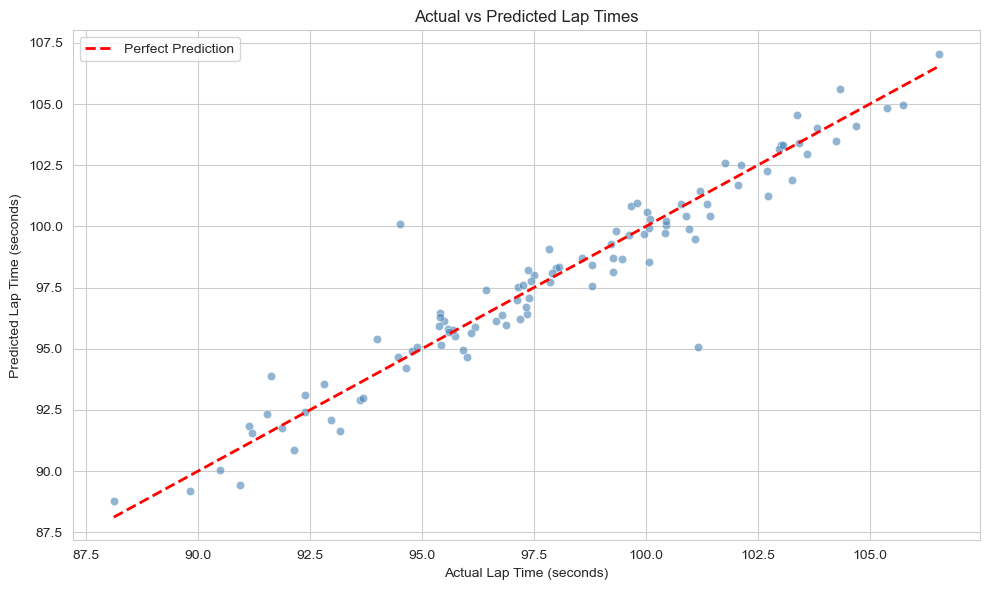

In [66]:
plt.figure(figsize=(10, 6))

plt.scatter(y_test, y_pred, color='steelblue', alpha=0.6, edgecolors='white', linewidth=0.5)

# Perfect prediction line — if every prediction was exact
# all dots would sit on this line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linewidth=2, linestyle='--', label='Perfect Prediction')

plt.xlabel('Actual Lap Time (seconds)')
plt.ylabel('Predicted Lap Time (seconds)')
plt.title('Actual vs Predicted Lap Times')
plt.legend()
plt.tight_layout()
plt.show()

## *Plot 2 — Tyre Age vs Lap Time with Regression Line*

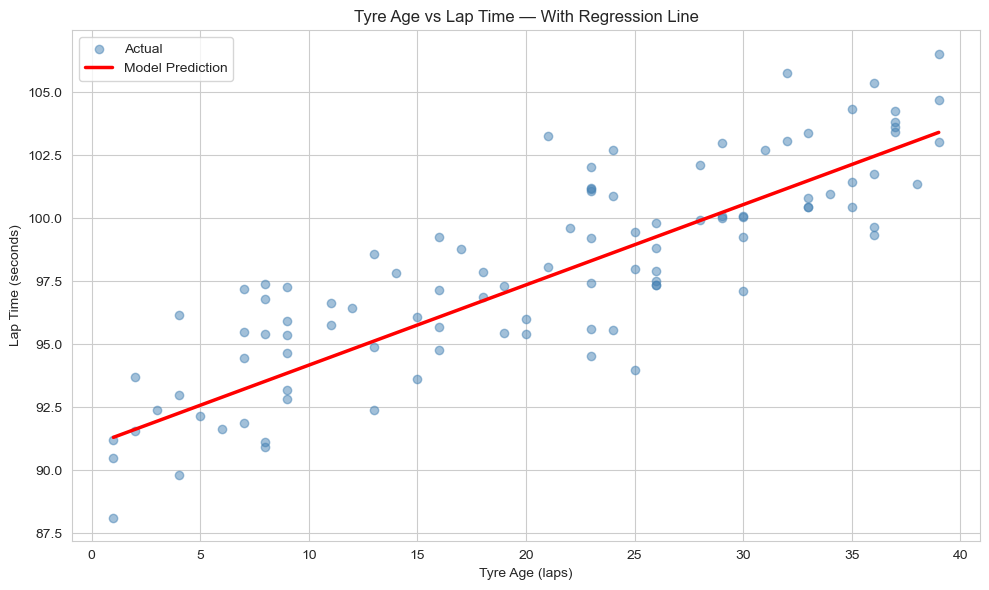

In [67]:
plt.figure(figsize=(10, 6))

# Actual points
plt.scatter(X_test['tyre_age'], y_test,
            color='steelblue', alpha=0.5, label='Actual')

# Create a smooth range of tyre age values
tyre_range = np.linspace(X_test['tyre_age'].min(), 
                         X_test['tyre_age'].max(), 300)

# Build a full feature set using median values for other features
# so tyre_age is the only thing changing
smooth_X = pd.DataFrame({
    'tyre_age':          tyre_range,
    'fuel_load':         np.full(300, X_test['fuel_load'].median()),
    'track_temp':        np.full(300, X_test['track_temp'].median()),
    'starting_position': np.full(300, X_test['starting_position'].median())
})

smooth_pred = model.predict(smooth_X)

plt.plot(tyre_range, smooth_pred,
         color='red', linewidth=2.5, label='Model Prediction')

plt.xlabel('Tyre Age (laps)')
plt.ylabel('Lap Time (seconds)')
plt.title('Tyre Age vs Lap Time — With Regression Line')
plt.legend()
plt.tight_layout()
plt.show()